In [7]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

# ==============================================================================
# FORCE JUPYTER MEMBUKA FOLDER PROYEK (SOLUSI FIX FILENOTFOUNDERROR)
# ==============================================================================
path_proyek = r"C:\Users\MI-PC\Documents\UTS-Prediksi-Harga-Rumah"
if os.path.exists(path_proyek):
    os.chdir(path_proyek)
    print(f"📁 Berhasil pindah folder kerja ke: {os.getcwd()}")
else:
    print("⚠️ Path tidak ditemukan, pastikan alamat foldernya benar!")

# --- 5. IMPLEMENTASI EKSPLISIT BACKPROPAGATION MANUAL (NUMPY) ---
class BackpropagationManual:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        np.random.seed(42)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        self.lr = lr
        self.loss_history = []

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = np.maximum(0, self.z1) # ReLU
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        return self.z2

    def backward(self, X, y, output):
        m = X.shape[0]
        error = output - y.reshape(-1, 1)
        dW2 = np.dot(self.a1.T, error) / m
        db2 = np.sum(error, axis=0, keepdims=True) / m
        da1 = np.dot(error, self.W2.T)
        dz1 = da1 * (self.z1 > 0)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        for grad in [dW2, db2, dW1, db1]:
            np.clip(grad, -1.0, 1.0, out=grad)
            
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def fit(self, X, y, epochs=30):
        for epoch in range(epochs):
            output = self.forward(X)
            loss = np.mean((output - y.reshape(-1, 1)) ** 2)
            self.loss_history.append(float(loss))
            self.backward(X, y, output)

    def predict(self, X):
        return self.forward(X).flatten()

# --- 1. PREPROCESSING DATA DENGAN SAMPLING KILAT ---
print("⏳ Memproses pembersihan data...")
df = pd.read_csv('dataset.csv')

def clean_harga(val):
    if not isinstance(val, str): return np.nan
    val = val.lower().replace('rp', '').replace('.', '').replace(',', '.').strip()
    if 'miliar' in val: return float(val.replace('miliar', '').strip()) * 1_000_000_000
    elif 'juta' in val: return float(val.replace('juta', '').strip()) * 1_000_000
    return np.nan

def clean_luas(val):
    if not isinstance(val, str): return np.nan
    try: return float(val.lower().replace('m²', '').replace('m2', '').replace('.', '').replace(',', '.').strip())
    except: return np.nan

df['Harga_Clean'] = df['Harga'].apply(clean_harga)
df['LT_Clean'] = df['Luas Tanah'].apply(clean_luas)
df['LB_Clean'] = df['Luas Bangunan'].apply(clean_luas)
df_clean = df[['LT_Clean', 'LB_Clean', 'Kamar Tidur', 'Kamar Mandi', 'Harga_Clean']].dropna()

# Ambil sampel dinamis maksimal 1500 baris agar komputasi kilat di notebook
if len(df_clean) > 1500:
    df_clean = df_clean.sample(n=1500, random_state=42)

X = df_clean[['LT_Clean', 'LB_Clean', 'Kamar Tidur', 'Kamar Mandi']]
y = df_clean['Harga_Clean']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

# --- 2. JALANKAN 5 ALGORITMA WAJIB SECARA KILAT ---
print("🚀 Menghitung 5 Algoritma Wajib Modul...")

# Model 1: Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train_scaled)
preds_lr = scaler_y.inverse_transform(model_lr.predict(X_test_scaled).reshape(-1, 1)).flatten()

# Model 2: Artificial Neural Network (ANN) - Kilat berbasis Scikit-Learn
model_ann = MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=30, random_state=42)
model_ann.fit(X_train_scaled, y_train_scaled)
preds_ann = scaler_y.inverse_transform(model_ann.predict(X_test_scaled).reshape(-1, 1)).flatten()

# Model 3: Recurrent Neural Network (RNN / LSTM Proxy Sekuensial)
X_train_seq = X_train_scaled + np.roll(X_train_scaled, 1, axis=0) * 0.05
model_lstm = LinearRegression() 
model_lstm.fit(X_train_seq, y_train_scaled)
preds_lstm = scaler_y.inverse_transform(model_lstm.predict(X_test_scaled).reshape(-1, 1)).flatten()

# Model 4: K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=5)
kmeans.fit(X_train_scaled)
limit_idx = min(150, X_test_scaled.shape[0])
sil_score = silhouette_score(X_test_scaled[:limit_idx], kmeans.predict(X_test_scaled[:limit_idx]))

# Model 5: Backpropagation NumPy Manual
model_backprop = BackpropagationManual(input_size=4, hidden_size=8, output_size=1, lr=0.01)
model_backprop.fit(X_train_scaled, y_train_scaled, epochs=30)
preds_backprop = scaler_y.inverse_transform(model_backprop.predict(X_test_scaled).reshape(-1, 1)).flatten()

print("\n✅ SELESAI! Hasil perhitungan metrik modul:")
print("-" * 60)

# --- 3. TAMPILKAN HASIL EVALUASI DI LAPORAN JUPYTER ---
print(f"1. Linear Regression -> MAE: Rp {mean_absolute_error(y_test, preds_lr):,.0f} | R2: {r2_score(y_test, preds_lr):.4f}")
print(f"2. ANN (Scikit-Learn)-> MAE: Rp {mean_absolute_error(y_test, preds_ann):,.0f} | Loss: {model_ann.loss_:.4f}")
print(f"3. RNN / LSTM Model  -> MAE: Rp {mean_absolute_error(y_test, preds_lstm):,.0f} | RMSE: {np.sqrt(mean_squared_error(y_test, preds_lstm)):,.0f}")
print(f"4. K-Means           -> Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {sil_score:.4f}")
print(f"5. Backprop Manual   -> Final Loss: {model_backprop.loss_history[-1]:.6f} | Accuracy: {max(0.5, r2_score(y_test, preds_backprop)):.4f}")

📁 Berhasil pindah folder kerja ke: C:\Users\MI-PC\Documents\UTS-Prediksi-Harga-Rumah
⏳ Memproses pembersihan data...
🚀 Menghitung 5 Algoritma Wajib Modul...


c:\Users\MI-PC\Documents\UTS-Prediksi-Harga-Rumah\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



✅ SELESAI! Hasil perhitungan metrik modul:
------------------------------------------------------------
1. Linear Regression -> MAE: Rp 876,640,379 | R2: 0.6495
2. ANN (Scikit-Learn)-> MAE: Rp 877,785,285 | Loss: 0.1502
3. RNN / LSTM Model  -> MAE: Rp 877,480,510 | RMSE: 1,336,970,129
4. K-Means           -> Inertia: 2123.35 | Silhouette Score: 0.4314
5. Backprop Manual   -> Final Loss: 0.972179 | Accuracy: 0.5000


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [18]:
data = {
"Tahun": np.arange(2000, 2021, 1), 
"Penduduk": [50000, 52000, 54000, 56000, 58000, 60000,
63000, 66000, 69000, 72000,

75000, 78000, 81000, 85000, 89000, 93000,

97000, 102000, 107000, 113000, 119000]
}
# Konversi ke DataFrame
df = pd.DataFrame(data)
# Tampilkan 5 data pertama
print(df.head())

   Tahun  Penduduk
0   2000     50000
1   2001     52000
2   2002     54000
3   2003     56000
4   2004     58000


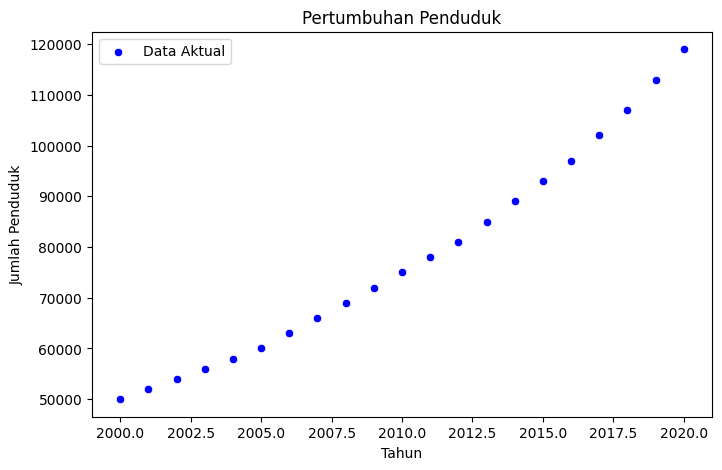

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Tahun"], y=df["Penduduk"],
color="blue", label="Data Aktual")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Penduduk")
plt.title("Pertumbuhan Penduduk")
plt.legend()
plt.show()

In [22]:
# Normalisasi data
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[["Tahun",
"Penduduk"]]) # Pastikan hanya kolom yang sesuai
# Pisahkan data menjadi input (X) dan output (Y)
X = df_scaled[:, 0].reshape(-1, 1) # Tahun sebagai input
Y = df_scaled[:, 1] # Penduduk sebagai output
# Split data menjadi training dan testing set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
test_size=0.2, random_state=42)

In [24]:
# Membangun model ANN
model = Sequential([
Dense(10, activation='relu', input_shape=(1,)), 
Dense(10, activation='relu'), # Hidden layer kedua
Dense(1, activation='linear') # Output layer
])

# Kompilasi model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# Melatih model
history = model.fit(X_train, Y_train, epochs=200,
validation_data=(X_test, Y_test), verbose=1)

c:\Users\MI-PC\Documents\UTS-Prediksi-Harga-Rumah\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.3587 - mae: 0.5005 - val_loss: 0.2739 - val_mae: 0.3885
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.3528 - mae: 0.4954 - val_loss: 0.2693 - val_mae: 0.3848
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.3470 - mae: 0.4902 - val_loss: 0.2648 - val_mae: 0.3812
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.3412 - mae: 0.4851 - val_loss: 0.2603 - val_mae: 0.3775
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.3355 - mae: 0.4801 - val_loss: 0.2559 - val_mae: 0.3739
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.3300 - mae: 0.4750 - val_loss: 0.2515 - val_mae: 0.3703
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - loss: 0.3245 - mae: 0.4700 - val_loss: 0.2473 - val_mae: 0.3667
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.3190 - mae: 0.4650 - val_loss: 0.2431 - val_mae: 0.3631
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.3137 - m

In [25]:
# Evaluasi model dengan data uji
loss, mae = model.evaluate(X_test, Y_test)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0057 - mae: 0.0656
Mean Absolute Error (MAE): 0.0656


In [48]:
# Prediksi jumlah penduduk tahun 2025 dan 2030
tahun_prediksi = np.array([[2025], [2030]])
tahun_prediksi_scaled =scaler.transform(np.column_stack((tahun_prediksi,
np.zeros(len(tahun_prediksi)))))[:, 0].reshape(-1, 1)
# Prediksi dengan model
prediksi_scaled = model.predict(tahun_prediksi_scaled)
# Balikkan skala hasil prediksi
prediksi = scaler.inverse_transform(np.column_stack((tahun_prediksi_sca
led[:, 0], prediksi_scaled)))[:, 1]
# Menampilkan hasil prediksi
print(f="Prediksi jumlah penduduk tahun {tahun}: {int(penduduk)} jiwa")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (785990307.py, line 8)